# Analyzing the Boresch restraint geometry

A Boresch-style restraint restrains a ligand to its bound pose while its nonbonded interactions are switched off during a binding free energy calculation and is used in both ABFE and SepTop approaches. 
Once a ligand is fully decoupled, the restraint is the only interaction holding it in place, since no protein-ligand nonbonded contacts remain to do so. 
A restraint that is too loose, or anchored to a poor choice of atoms, may allow the ligand to drift or sample a pose other than the one intended, manifesting downstream as noisy per-repeat free energy estimates or slow convergence. Plotting the restraint's geometry against its equilibrium reference values provides a quick diagnostic for this failure mode.

The `BoreschRestraintAnalysis` in **openfe_analysis** computes a Boresch restraint's bond, two angles, and three dihedrals over a trajectory, for an `MDAnalysis.AtomGroup` of 6 atoms ordered `[H0, H1, H2, G0, G1, G2]` (host atoms then guest atoms).

This notebook shows how do perform the restraint analysis for the SepTop protocol. Given a SepTop results JSON and its trajectory/topology files, we locate the restraint's atom indices and equilibrium reference values, run `BoreschRestraintAnalysis` across every lambda window, and plot the first and last against the reference values, as a visual check for whether the restraint remained well-behaved during the simulation. 
The same pattern applies to ABFE results, both protocols serialize restraint geometry as the same `BoreschRestraintGeometry` object with the difference that SepTop has two sets of Boresch-style restraints, one for each ligand, while ABFE has a single `BoreschRestraintGeometry` object.

## 1. Imports

In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import MDAnalysis as mda
import netCDF4 as nc
import numpy as np
import pooch
from gufe.tokenization import JSON_HANDLER
from openfe_analysis import FEReader
from openfe_analysis.restraints import BoreschRestraintAnalysis
from openfe_analysis.utils.universe_utils import create_universe_single_state
from openff.units import Quantity, unit

## 2. Download tutorial data

In [35]:
septop_files = pooch.retrieve(
    url="https://zenodo.org/records/21872497/files/septop_boresch_analysis.tar.gz",
    known_hash="md5:e692f6b1cb6b43ba2986394cc887f327",
    processor=pooch.Untar(extract_dir="septop_boresch_analysis"),
)

septop_paths = {pathlib.Path(f).suffix: pathlib.Path(f) for f in septop_files}
results_json = septop_paths[".json"]
trajectory_nc = septop_paths[".nc"]
subsampled_pdb = septop_paths[".pdb"]

## 3. Load the results JSON

In [28]:
with open(results_json, "r") as f:
    results = json.load(f, cls=JSON_HANDLER.decoder)

## 4. Find the complex-leg Analysis unit outputs

The output of the SepTop Analysis Unit of the complex-leg includes everything we need:
`restraint_geometry_A/B` (atom indices and equilibrium reference values),
and `selection_indices` (how full-system atom indices map onto the
subsampled trajectory in `subsampled_pdb`/`trajectory_nc`). 

This example dataset contains a single repeat, so we take the first
complex-leg Analysis Unit found. For multi-repeat data, match
`outputs["repeat_id"]` against the specific repeat whose trajectory you're
loading as SepTop can pick a different Boresch restraint per repeat.

In [29]:
complex_analysis_outputs = None

for key, unit_result in results["unit_results"].items():
    if not key.startswith("ProtocolUnitResult"):
        continue
    if "Analysis" not in unit_result.get("name", ""):
        continue
    outputs = unit_result["outputs"]
    if outputs.get("simtype") != "complex":
        continue
    complex_analysis_outputs = outputs
    break

## 5. Helper: translate full-system atom indices

`host_atoms`/`guest_atoms` in the restraint geometry are full-system
indices, but the trajectory only contains the subsampled atoms
(`selection_indices`). Here, we have a small function to help find the atom indices of the Boresch atoms in the subsampled system.

In [30]:
def translate_to_subsampled_indices(full_system_indices, selection_indices):
    """
    Translate a list of full-system atom indices into their positions
    within `selection_indices`, preserving the original order.
    """
    selection_indices_list = selection_indices.tolist()
    return [selection_indices_list.index(idx) for idx in full_system_indices]

## 6. Helper: reconstruct a Quantity from the stored restraint geometry

Restraint geometry fields (`r_aA0`, `theta_A0`, ...) are gufe `Quantity`
fields, serialized as a dictionary: `{"val": <float>, "unit": "<pint unit string>"}`. Here, we have a small helper function that reconstructs the `openff.units.Quantity`.

In [31]:
def quantity_from_geom(geom: dict, key: str) -> Quantity:
    field = geom[key]
    return Quantity(field["val"], field["unit"])

## 7. Run `BoreschRestraintAnalysis` across every lambda window

For each ligand (A and B), this translates the restraint's
`host_atoms`/`guest_atoms` into subsampled indices, then runs
`BoreschRestraintAnalysis` at every lambda window, storing the full per-state time series. 

In [32]:
selection_indices = np.asarray(complex_analysis_outputs["selection_indices"])
analysis_results = {}  

with nc.Dataset(trajectory_nc) as ds:
    n_lambda = ds.dimensions["state"].size

    if hasattr(ds, "PositionInterval"):
        n_frames = len(range(0, ds.dimensions["iteration"].size, ds.PositionInterval))
    else:
        n_frames = ds.dimensions["iteration"].size

    skip = max(n_frames // 500, 1)

    u_top = mda.Universe(subsampled_pdb)

    for ligand in ("A", "B"):
        geom_key = f"restraint_geometry_{ligand}"
        geom = complex_analysis_outputs[geom_key]
        host_atoms_full = geom["host_atoms"]
        guest_atoms_full = geom["guest_atoms"]

        host_atoms = translate_to_subsampled_indices(host_atoms_full, selection_indices)
        guest_atoms = translate_to_subsampled_indices(guest_atoms_full, selection_indices)
        restraint_atom_indices = host_atoms + guest_atoms

        reference_values = [
            quantity_from_geom(geom, "r_aA0").m_as(unit.angstrom),
            quantity_from_geom(geom, "theta_A0").m_as(unit.radians),
            quantity_from_geom(geom, "theta_B0").m_as(unit.radians),
            quantity_from_geom(geom, "phi_A0").m_as(unit.radians),
            quantity_from_geom(geom, "phi_B0").m_as(unit.radians),
            quantity_from_geom(geom, "phi_C0").m_as(unit.radians),
        ]

        output: dict[str, list] = {
            "bond": [],
            "angle1": [],
            "angle2": [],
            "dihedral1": [],
            "dihedral2": [],
            "dihedral3": [],
        }

        for state_idx in range(n_lambda):
            universe = create_universe_single_state(u_top._topology, ds, state_idx)
            restraint_ag = universe.atoms[restraint_atom_indices]
            restraint_analysis = BoreschRestraintAnalysis(restraint_ag).run(step=skip)

            output["bond"].append(restraint_analysis.results.bond)
            output["angle1"].append(restraint_analysis.results.angle1)
            output["angle2"].append(restraint_analysis.results.angle2)
            output["dihedral1"].append(restraint_analysis.results.dihedral1)
            output["dihedral2"].append(restraint_analysis.results.dihedral2)
            output["dihedral3"].append(restraint_analysis.results.dihedral3)

        analysis_results[ligand] = {"reference_values": reference_values, **output}

/Users/hannahbaumann/.local/share/mamba/envs/openfe/lib/python3.13/site-packages/parmed/utils/netcdf.py:46: DeprecationWarning: `np.compat`, which was used during the Python 2 to 3 transition, is deprecated since 1.26.0, and will be removed
  from numpy.compat import asbytes, asstr


## 8. Plot the results

We plot the first and last lambda windows which are usually the
most informative pair to check, since it confirms the restraint behaves
consistently at both ends of the alchemical pathway. Pass `windows=[...]` to plot a
different subset.

In [50]:
STATE_COLORS = {
    "interacting, unrestrained": "#8a2283",
    "non-interacting, restrained": "#00bdaa",
}

def label_lambda_window(ligand, window, n_lambda):
    """
    Helper function to label lambda window.
    """
    if n_lambda <= 1 or window not in (0, n_lambda - 1):
        return f"lambda_{window}"
    is_first_window = window == 0
    if ligand == "A":
        return "interacting, unrestrained" if is_first_window else "non-interacting, restrained"
    if ligand == "B":
        return "non-interacting, restrained" if is_first_window else "interacting, unrestrained"
    return f"lambda_{window}"

In [53]:
def plot_boresch_restraint(analysis_results_for_ligand, ligand_label, ligand, windows=None):
    """
    Plot BoreschRestraintAnalysis results for selected lambda windows
    against their reference values.

    Parameters
    ----------
    analysis_results_for_ligand : dict
        One ligand's entry from `analysis_results`: a dict with keys
        "reference_values", "bond", "angle1", "angle2", "dihedral1",
        "dihedral2", "dihedral3" -- each (other than "reference_values")
        a list indexed by lambda state.
    ligand_label : str
        Used in the figure title.
    ligand : str
        "A" or "B" 
    windows : list[int], optional
        Which lambda state indices to plot. Defaults to the first and last
        state.
    """
    titles = ["bond", "angle1", "angle2", "dihedral1", "dihedral2", "dihedral3"]
    reference_values = analysis_results_for_ligand["reference_values"]
    n_lambda = len(analysis_results_for_ligand["bond"])

    if windows is None:
        windows = [0, n_lambda - 1] if n_lambda > 1 else [0]

    fig = plt.figure(figsize=(8, 4))
    first_ax = None
    for window in windows:
        label = label_lambda_window(ligand, window, n_lambda)
        color = STATE_COLORS.get(label)
        for i, attr in enumerate(titles):
            values = analysis_results_for_ligand[attr][window]
            ax = plt.subplot(2, 3, i + 1)
            ax.plot(values, label=label, color=color)
            ax.plot([reference_values[i]] * len(values), "--", c="black")
            ax.set_title(attr)
            if first_ax is None:
                first_ax = ax

    handles, labels = first_ax.get_legend_handles_labels()
    fig.suptitle(f"Boresch restraint {ligand_label}", fontsize=10, y=1.08)
    fig.legend(
        handles, labels,
        loc="upper center", bbox_to_anchor=(0.5, 0.99),
        ncol=len(handles), fontsize=10, frameon=False,
    )
    fig.tight_layout()
    return fig

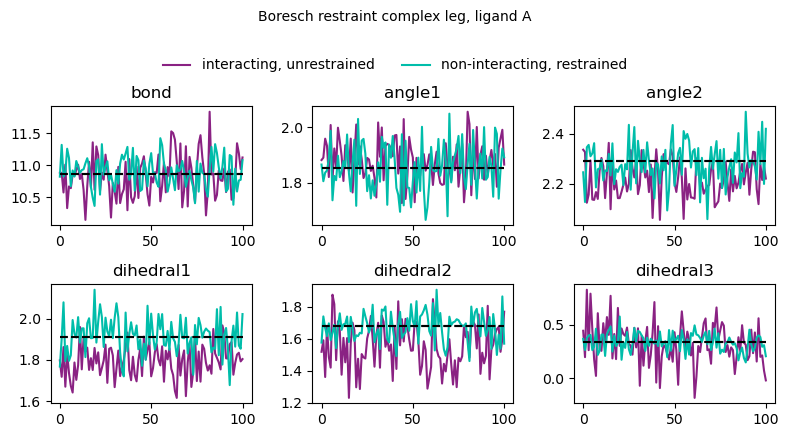

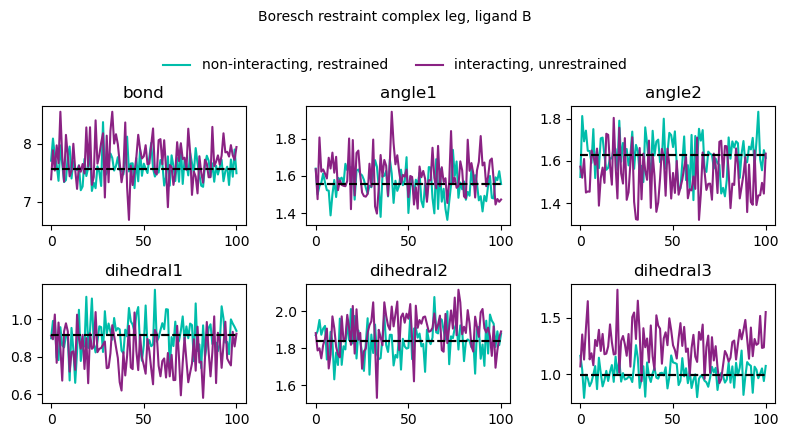

In [54]:
for ligand, data in analysis_results.items():
    fig = plot_boresch_restraint(data, ligand_label=f"complex leg, ligand {ligand}", ligand=ligand)
    plt.show()
    plt.close(fig)

## What to look for

For a well-behaved restraint, each quantity (`bond`, `angle1`, `angle2`,
`dihedral1`, `dihedral2`, `dihedral3`) should fluctuate around its dashed
reference line, for both the first and last lambda window. If a quantity
sits at a consistent offset from the reference line rather than fluctuating
around it, that's worth investigating.